#  Face Recognition on the AT&T Database of Faces

Dataset: [AT&T Database of Faces](https://www.kaggle.com/datasets/kasikrit/att-database-of-faces/data)  
- 40 subjects x 10 images = 400 images  
- Split: 8 train images / 2 test images per subject  
- Format: PGM, 92x112 pixels, 256 grayscale levels  

Methods compared:
1. LBPH (Local Binary Patterns Histograms) — texture descriptor + Chi2 distance  
2. Eigenfaces — dimensionality reduction + maximum-margin classifier


##  Imports and configuration

In [1]:
import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)
from skimage.feature import local_binary_pattern

print(" Imports done")


 Imports done


## 1. Loading the dataset

The AT&T dataset is loaded from the Kaggle path. Each PGM image is read with PIL
and converted to a NumPy array. Labels range from 0 to 39 (40 subjects).


In [2]:
DATASET_PATH = "/kaggle/input/datasets/kasikrit/att-database-of-faces"

def load_dataset(dataset_path):
    X, y = [], []
    for subject_id in range(1, 41):           # s1 to s40
        folder = os.path.join(dataset_path, f"s{subject_id}")
        for image_id in range(1, 11):         # 1.pgm to 10.pgm
            img_path = os.path.join(folder, f"{image_id}.pgm")
            img = Image.open(img_path)
            X.append(np.array(img))
            y.append(subject_id - 1)          # labels 0-39
    return np.array(X), np.array(y)

X, y = load_dataset(DATASET_PATH)

print(f"Images shape  : {X.shape}  ->  (N, height, width)")
print(f"Labels shape  : {y.shape}")
print(f"Pixel values  : {X.min()} - {X.max()}")
print(f"Subjects      : {len(np.unique(y))}")


Images shape  : (400, 112, 92)  ->  (N, height, width)
Labels shape  : (400,)
Pixel values  : 0 - 251
Subjects      : 40


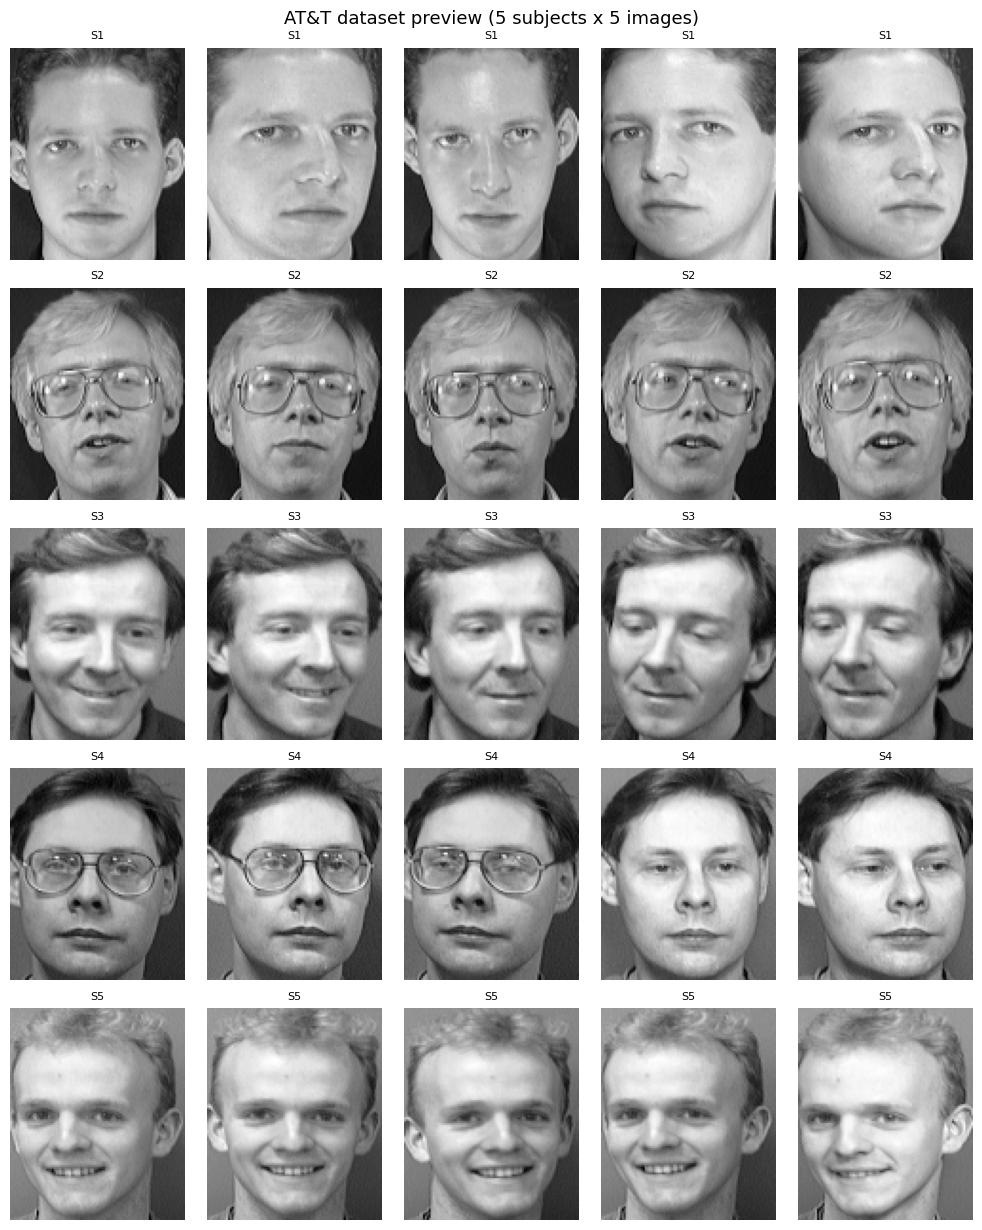

In [3]:
def show_sample(X, y, n_subjects=5, n_images=5):
    fig, axes = plt.subplots(n_subjects, n_images, figsize=(n_images * 2, n_subjects * 2.5))
    for i in range(n_subjects):
        indices = np.where(y == i)[0][:n_images]
        for j, idx in enumerate(indices):
            axes[i, j].imshow(X[idx], cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f"S{i+1}", fontsize=8)
    plt.suptitle("AT&T dataset preview (5 subjects x 5 images)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_sample(X, y)


## 2. Train / Test split

Manual stratified split: **8 training images** and **2 test images** per subject,  
i.e. 320 train images and 80 test images in total.


In [4]:
def split_dataset(X, y, n_train=8):
    X_train, X_test, y_train, y_test = [], [], [], []
    for subject_id in range(40):
        indices = np.where(y == subject_id)[0]
        np.random.shuffle(indices)
        X_train.append(X[indices[:n_train]])
        X_test.append(X[indices[n_train:]])
        y_train.append(y[indices[:n_train]])
        y_test.append(y[indices[n_train:]])
    return (np.concatenate(X_train), np.concatenate(X_test),
            np.concatenate(y_train), np.concatenate(y_test))

np.random.seed(42)
X_train, X_test, y_train, y_test = split_dataset(X, y)

print(f"X_train : {X_train.shape}  ->  {len(np.unique(y_train))} subjects x 8 images")
print(f"X_test  : {X_test.shape}   ->  {len(np.unique(y_test))} subjects x 2 images")


X_train : (320, 112, 92)  ->  40 subjects x 8 images
X_test  : (80, 112, 92)   ->  40 subjects x 2 images


---
##  Method 1 — LBPH (Local Binary Patterns Histograms)

### Principle

**LBP** (Local Binary Pattern) is a local texture descriptor:  
for each pixel, its value is compared to its neighbours on a circle of radius `R`.  
The result is a binary code encoding the local micro-texture.

The image is then split into **blocks** and an LBP histogram is computed  
per block -> the concatenated histograms form the image's **LBPH descriptor**.

**Classification**: comparison by **Chi2 distance** between the test descriptor  
and the mean model of each subject. The closest subject wins.

**Key parameters:**
- `RADIUS = 1`: neighbourhood radius
- `N_POINTS = 8`: number of neighbours
- `METHOD = 'uniform'`: only patterns with <= 2 binary transitions are kept
- `BLOCK_SIZE = 8`: block size in pixels


In [5]:
# -- LBP parameters -----------------------------------------------------------
RADIUS     = 1
N_POINTS   = 8 * RADIUS
METHOD     = 'uniform'
BLOCK_SIZE = 8

# -- Distance functions -------------------------------------------------------
def chi2_distance(hist1, hist2, eps=1e-10):
    """Chi2 distance between two normalised histograms."""
    return 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + eps))

def euclidean_distance(hist1, hist2):
    """Euclidean distance between two histograms."""
    return np.sqrt(np.sum((hist1 - hist2) ** 2))

def kl_divergence(hist1, hist2, eps=1e-10):
    """Symmetrised Kullback-Leibler divergence (KL(P||Q) + KL(Q||P)) / 2."""
    p = hist1 + eps
    q = hist2 + eps
    return 0.5 * (np.sum(p * np.log(p / q)) + np.sum(q * np.log(q / p)))

DISTANCE_FUNCTIONS = {
    'Chi2':      chi2_distance,
    'Euclidean': euclidean_distance,
    'KL':        kl_divergence,
}

def compute_lbp_histogram(image, n_points, radius, method, n_bins):
    """Normalised LBP histogram of an image block."""
    lbp = local_binary_pattern(image, n_points, radius, method)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def compute_lbp_histograms(X, n_points, radius, method, block_size):
    """Block-wise LBPH descriptors for a set of images."""
    descriptors = []
    img_h, img_w = X[0].shape
    n_bins = n_points + 2       # uniform LBP -> n_points + 2 bins
    for image in X:
        block_hists = []
        for row in range(0, img_h, block_size):
            for col in range(0, img_w, block_size):
                block = image[row:row+block_size, col:col+block_size]
                if block.shape[0] < block_size // 2 or block.shape[1] < block_size // 2:
                    continue
                block_hists.append(
                    compute_lbp_histogram(block, n_points, radius, method, n_bins)
                )
        descriptors.append(np.concatenate(block_hists))
    return np.array(descriptors)

def train_lbph(X_train, y_train, n_points, radius, method, block_size):
    """Train LBPH: compute the mean descriptor per subject."""
    print(f"Computing LBPH descriptors (block_size={block_size})...")
    descriptors = compute_lbp_histograms(X_train, n_points, radius, method, block_size)
    subject_models = {}
    for sid in np.unique(y_train):
        idx = np.where(y_train == sid)[0]
        subject_models[sid] = descriptors[idx].mean(axis=0)
    print(f"  -> {len(subject_models)} models | descriptor dim: {list(subject_models.values())[0].shape[0]}")
    return subject_models, descriptors

def predict_lbph(X_test, subject_models, n_points, radius, method, block_size,
                 distance_fn=None):
    """Predict by nearest neighbour (configurable distance) over the mean models."""
    if distance_fn is None:
        distance_fn = chi2_distance
    test_descriptors = compute_lbp_histograms(X_test, n_points, radius, method, block_size)
    y_pred = []
    scores = []   # confidence score = distance to nearest neighbour (min)
    for desc in test_descriptors:
        dists = {s: distance_fn(desc, subject_models[s]) for s in subject_models}
        best_sid = min(dists, key=dists.get)
        y_pred.append(best_sid)
        scores.append(dists[best_sid])
    return np.array(y_pred), test_descriptors, np.array(scores)

print(" LBPH functions defined (Chi2, Euclidean, KL)")

 LBPH functions defined (Chi2, Euclidean, KL)


In [6]:
# -- LBPH training ------------------------------------------------------------
t0 = time.time()
subject_models, train_descriptors = train_lbph(
    X_train, y_train, N_POINTS, RADIUS, METHOD, BLOCK_SIZE
)
t1 = time.time()
TIME_LBPH_TRAIN = t1 - t0
print(f"Training time   : {TIME_LBPH_TRAIN:.3f}s")

# -- Prediction (Chi2 by default) ---------------------------------------------
t2 = time.time()
y_pred_lbph, test_descriptors_lbph, scores_lbph = predict_lbph(
    X_test, subject_models, N_POINTS, RADIUS, METHOD, BLOCK_SIZE,
    distance_fn=chi2_distance
)
t3 = time.time()
TIME_LBPH_PRED = t3 - t2

print(f"Prediction time : {TIME_LBPH_PRED:.4f}s")
print(f"LBPH accuracy   : {accuracy_score(y_test, y_pred_lbph)*100:.2f}%")

Computing LBPH descriptors (block_size=8)...
  -> 40 models | descriptor dim: 1680
Training time   : 10.343s
Prediction time : 2.5025s
LBPH accuracy   : 90.00%


### 1.1 LBPH histograms per subject

Each histogram is the **mean descriptor** of the subject (averaged over its 8 images).  
Similar shapes indicate subjects that may be confused; distinct shapes  
point to good separability.


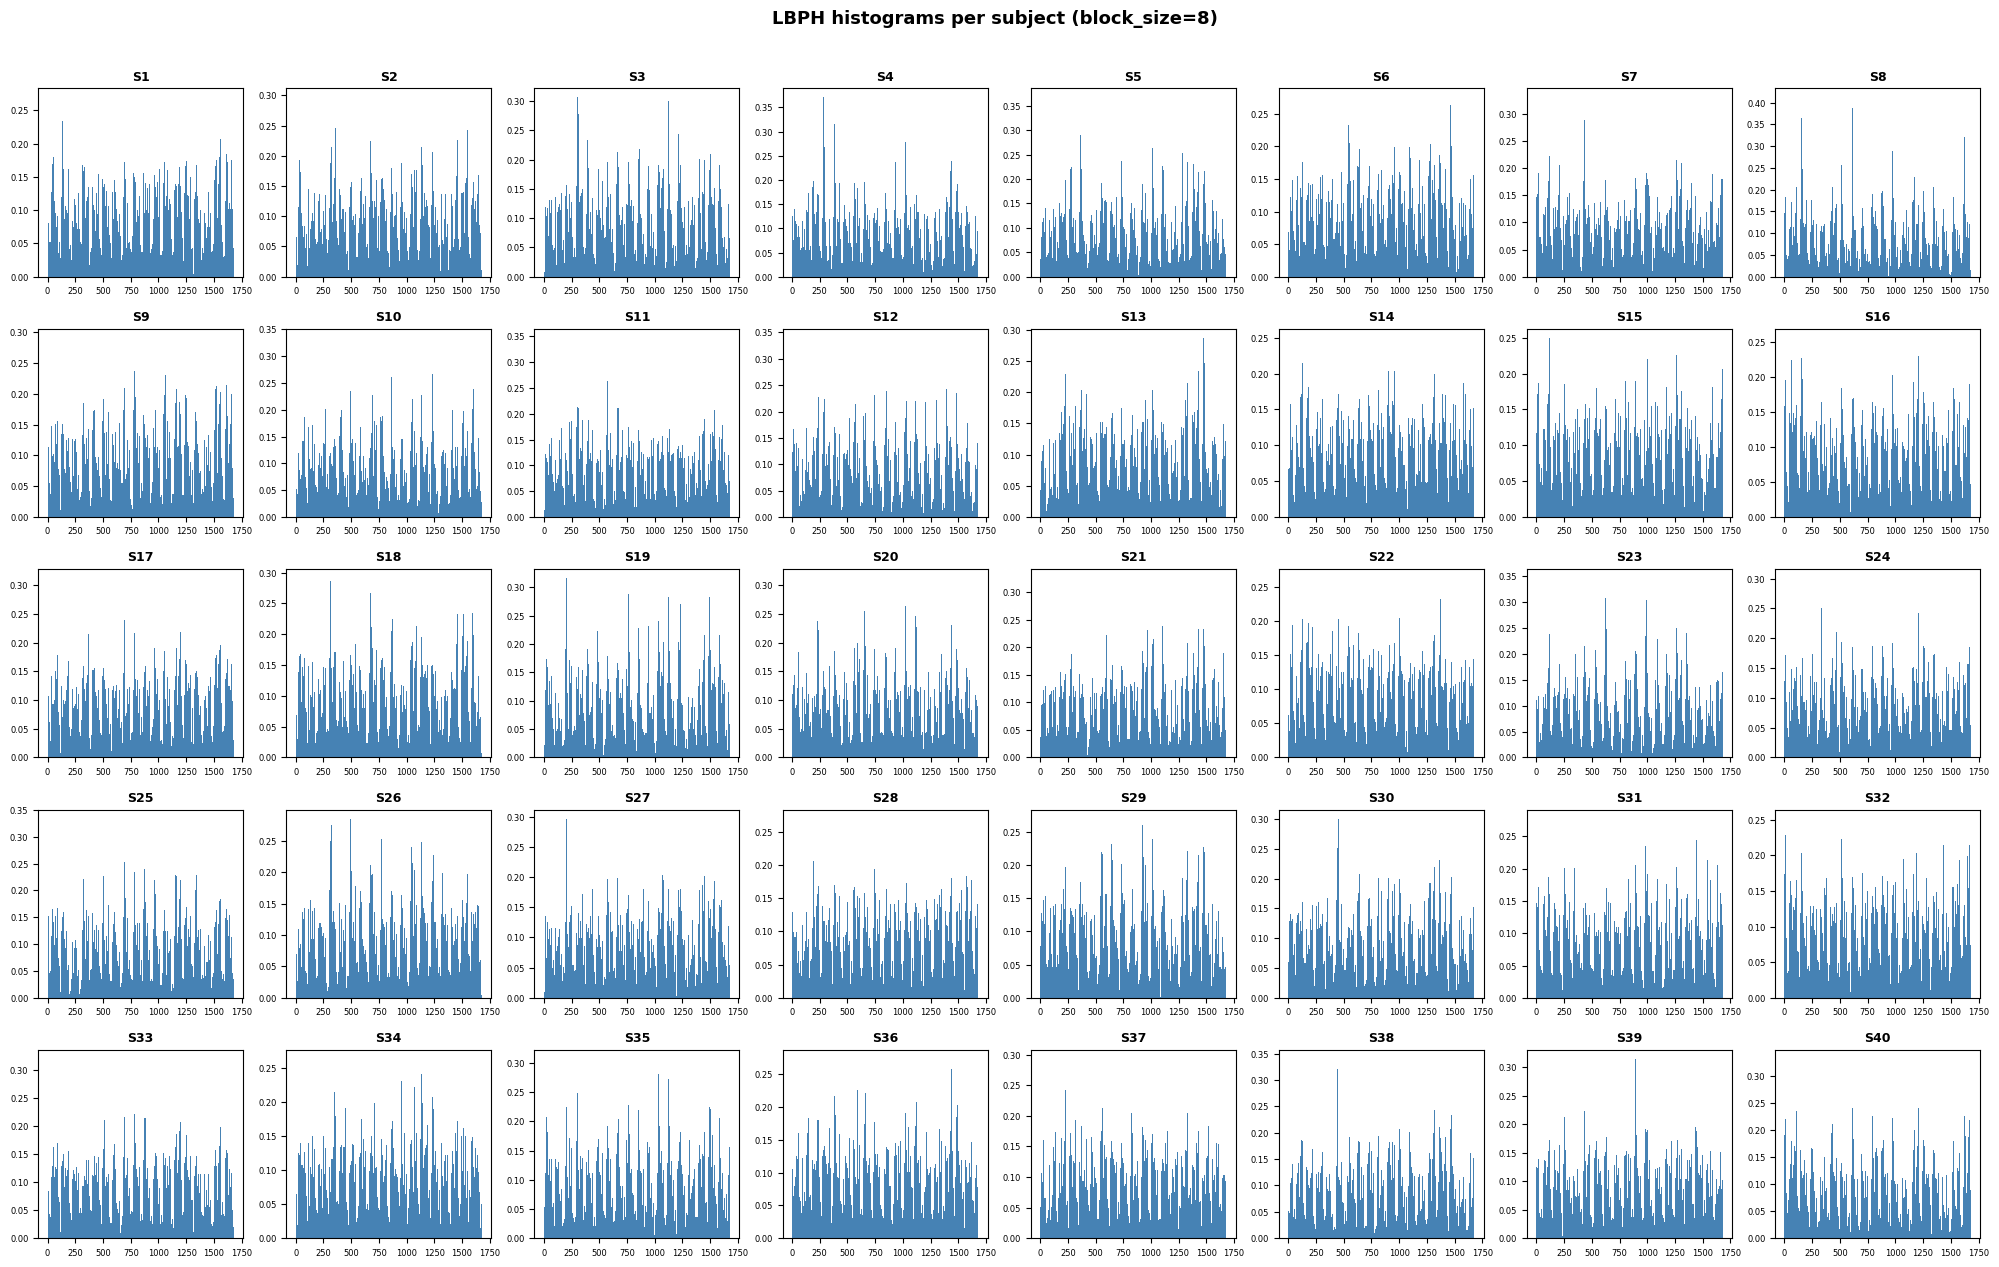

In [7]:
def plot_subject_histograms(subject_models, block_size, n_cols=8):
    n_subjects = len(subject_models)
    n_rows = int(np.ceil(n_subjects / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    axes = axes.ravel()
    for sid, model in subject_models.items():
        axes[sid].bar(range(len(model)), model, color='steelblue', width=1.0, edgecolor='none')
        axes[sid].set_title(f"S{sid+1}", fontsize=9, fontweight='bold')
        axes[sid].tick_params(labelsize=6)
    for i in range(n_subjects, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(f"LBPH histograms per subject (block_size={block_size})",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_subject_histograms(subject_models, BLOCK_SIZE)


### 1.2 Chi2 distance matrix between subjects

The diagonal should be zero (subject vs itself). Dark off-diagonal areas  
reveal subject pairs that are hard to tell apart -> potential sources of error.


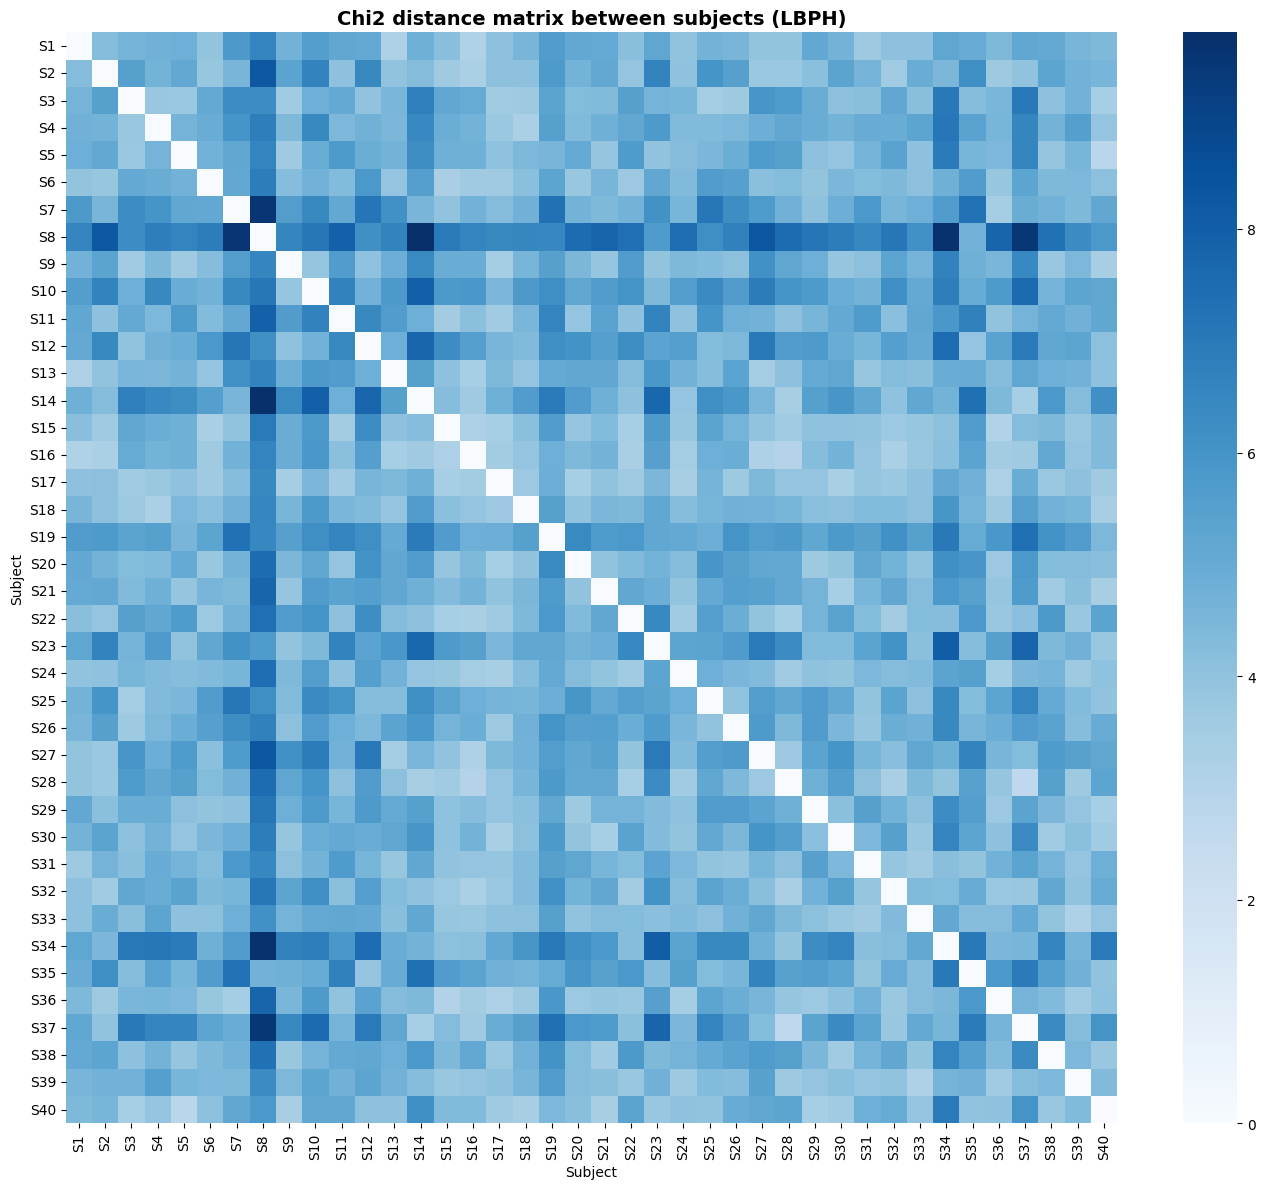

Intra-subject  -> mean: 0.0000 | max: 0.0000
Inter-subject  -> mean: 4.9238 | min: 2.6569
Inter/intra ratio : 49237799727.0x


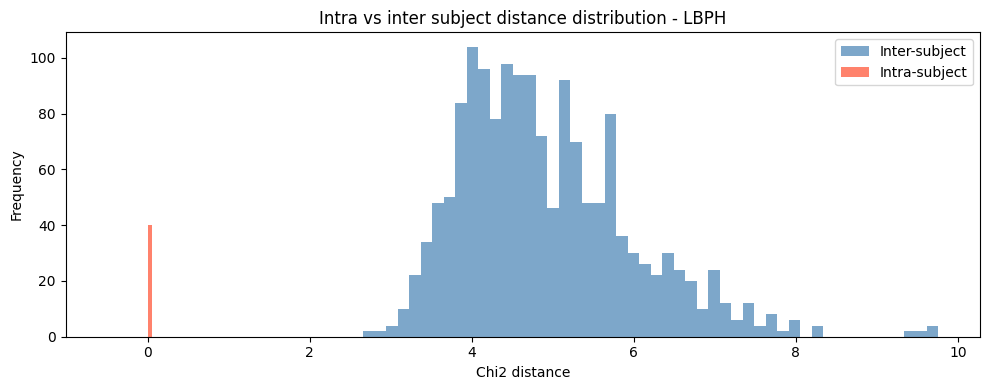

In [8]:
def plot_distance_matrix(subject_models):
    n = len(subject_models)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = chi2_distance(subject_models[i], subject_models[j])
    plt.figure(figsize=(14, 12))
    sns.heatmap(D, annot=False, cmap='Blues',
                xticklabels=[f"S{i+1}" for i in range(n)],
                yticklabels=[f"S{i+1}" for i in range(n)])
    plt.title("Chi2 distance matrix between subjects (LBPH)", fontsize=14, fontweight='bold')
    plt.xlabel("Subject"); plt.ylabel("Subject")
    plt.tight_layout(); plt.show()
    return D

distance_matrix = plot_distance_matrix(subject_models)

# Intra vs inter distribution
intra = [distance_matrix[i, i] for i in range(len(subject_models))]
inter = [distance_matrix[i, j] for i in range(len(subject_models))
                                for j in range(len(subject_models)) if i != j]
print(f"Intra-subject  -> mean: {np.mean(intra):.4f} | max: {max(intra):.4f}")
print(f"Inter-subject  -> mean: {np.mean(inter):.4f} | min: {min(inter):.4f}")
print(f"Inter/intra ratio : {np.mean(inter)/max(np.mean(intra), 1e-10):.1f}x")

plt.figure(figsize=(10, 4))
plt.hist(inter, bins=50, alpha=0.7, color='steelblue', label='Inter-subject')
plt.hist(intra, bins=20, alpha=0.8, color='tomato',    label='Intra-subject')
plt.xlabel("Chi2 distance"); plt.ylabel("Frequency")
plt.title("Intra vs inter subject distance distribution - LBPH")
plt.legend(); plt.tight_layout(); plt.show()


### Sensitivity to the `block_size` parameter (LBPH)

LBPH accuracy is evaluated for several `block_size` values:  
- **Small** (8): many blocks, fine textures, long vector  
- **Large** (56): few blocks, global structure, fewer details  


block_size = 4 ... Computing LBPH descriptors (block_size=4)...
  -> 40 models | descriptor dim: 6440
Accuracy : 82.5%
block_size = 8 ... Computing LBPH descriptors (block_size=8)...
  -> 40 models | descriptor dim: 1680
Accuracy : 90.0%
block_size = 14 ... Computing LBPH descriptors (block_size=14)...
  -> 40 models | descriptor dim: 560
Accuracy : 88.8%
block_size = 16 ... Computing LBPH descriptors (block_size=16)...
  -> 40 models | descriptor dim: 420
Accuracy : 85.0%
block_size = 28 ... Computing LBPH descriptors (block_size=28)...
  -> 40 models | descriptor dim: 120
Accuracy : 73.8%
block_size = 56 ... Computing LBPH descriptors (block_size=56)...
  -> 40 models | descriptor dim: 40
Accuracy : 50.0%


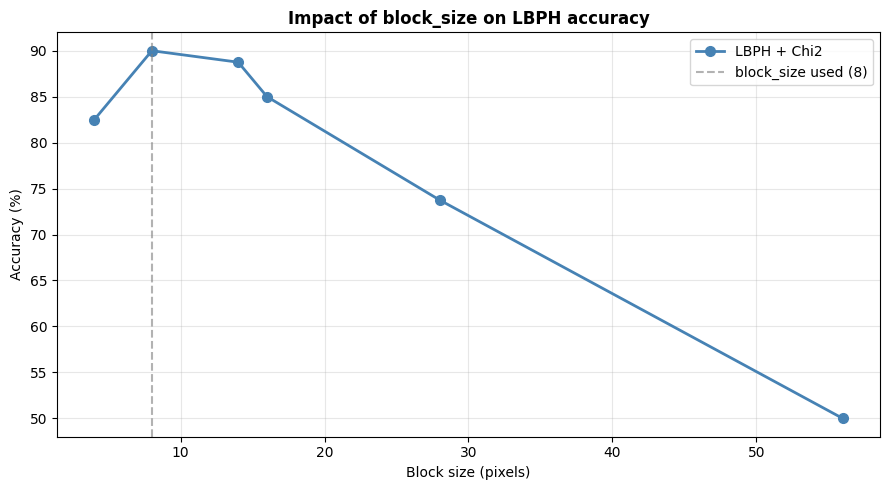

In [9]:
BLOCK_SIZES_TEST = [ 4, 8, 14, 16, 28, 56]
accs_lbph = []

for bs in BLOCK_SIZES_TEST:
    print(f"block_size = {bs} ...", end=" ", flush=True)
    models_bs, _ = train_lbph(X_train, y_train, N_POINTS, RADIUS, METHOD, bs)
    pred_bs, _, _ = predict_lbph(X_test, models_bs, N_POINTS, RADIUS, METHOD, bs)
    acc_bs  = accuracy_score(y_test, pred_bs)
    accs_lbph.append(acc_bs)
    print(f"Accuracy : {acc_bs*100:.1f}%")

# -- Plot ---------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(BLOCK_SIZES_TEST, [a*100 for a in accs_lbph],
         "o-", color="steelblue", linewidth=2, markersize=7, label="LBPH + Chi2")
plt.axvline(x=BLOCK_SIZE, color="gray", linestyle="--", alpha=0.6,
            label=f"block_size used ({BLOCK_SIZE})")
plt.xlabel("Block size (pixels)"); plt.ylabel("Accuracy (%)")
plt.title("Impact of block_size on LBPH accuracy", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 1.3 ROC curve — LBPH (Chi2)

The **ROC curve** measures the classifier's ability to separate each subject from the rest  
in a **one-vs-rest** setting. AUC (Area Under Curve) summarises performance:  
- AUC = 1.0: perfect separation  
- AUC = 0.5: random classifier  

The **Chi2 distance** is negated to act as a confidence score:  
a *low* distance corresponds to a *high* likelihood of belonging to the subject.


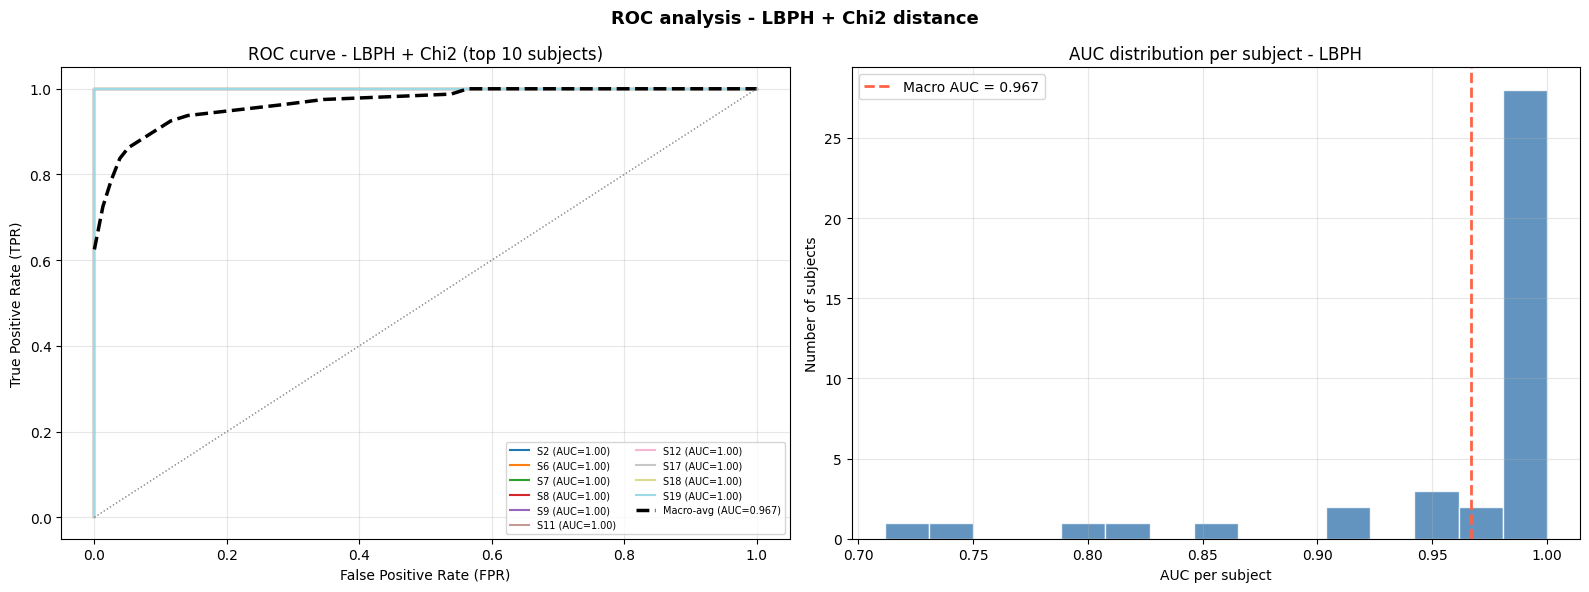


Macro-average AUC : 0.9670
AUC min : 0.7115  |  AUC max : 1.0000
Subjects with AUC < 0.95 : 8


In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_lbph(X_test, y_test, subject_models, n_points, radius, method,
                  block_size, distance_fn, distance_name, n_show=10):
    """
    One-vs-rest ROC curve for LBPH.
    The confidence score for subject s is: -distance(desc, model[s])
    (the lower the distance, the higher the score).
    """
    classes = sorted(subject_models.keys())
    n_classes = len(classes)

    # Test descriptors
    test_descs = compute_lbp_histograms(X_test, n_points, radius, method, block_size)

    # Score matrix (N_test x N_classes): score = -distance
    score_matrix = np.zeros((len(test_descs), n_classes))
    for j, sid in enumerate(classes):
        for i, desc in enumerate(test_descs):
            score_matrix[i, j] = -distance_fn(desc, subject_models[sid])

    # Label binarisation (one-vs-rest)
    y_bin = label_binarize(y_test, classes=classes)

    # Per-class AUC
    fpr_all, tpr_all, roc_auc_all = {}, {}, {}
    for j, sid in enumerate(classes):
        fpr_all[sid], tpr_all[sid], _ = roc_curve(y_bin[:, j], score_matrix[:, j])
        roc_auc_all[sid] = auc(fpr_all[sid], tpr_all[sid])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr_all[s] for s in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for sid in classes:
        mean_tpr += np.interp(all_fpr, fpr_all[sid], tpr_all[sid])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # -- Plot: n_show curves + macro-average ---------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: a few individual curves
    ax = axes[0]
    palette = plt.cm.tab20(np.linspace(0, 1, n_show))
    sorted_sids = sorted(classes, key=lambda s: -roc_auc_all[s])
    for k, sid in enumerate(sorted_sids[:n_show]):
        ax.plot(fpr_all[sid], tpr_all[sid], color=palette[k], lw=1.5,
                label=f"S{sid+1} (AUC={roc_auc_all[sid]:.2f})")
    ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5,
            label=f"Macro-avg (AUC={macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1)
    ax.set_xlabel("False Positive Rate (FPR)"); ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(f"ROC curve - LBPH + {distance_name} (top {n_show} subjects)")
    ax.legend(fontsize=7, loc="lower right", ncol=2)
    ax.grid(alpha=0.3)

    # Right: AUC distribution
    auc_values = [roc_auc_all[s] for s in classes]
    ax2 = axes[1]
    ax2.hist(auc_values, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    ax2.axvline(x=macro_auc, color='tomato', linestyle='--', lw=2,
                label=f"Macro AUC = {macro_auc:.3f}")
    ax2.set_xlabel("AUC per subject"); ax2.set_ylabel("Number of subjects")
    ax2.set_title("AUC distribution per subject - LBPH")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f"ROC analysis - LBPH + {distance_name} distance",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\nMacro-average AUC : {macro_auc:.4f}")
    print(f"AUC min : {min(auc_values):.4f}  |  AUC max : {max(auc_values):.4f}")
    print(f"Subjects with AUC < 0.95 : {sum(1 for a in auc_values if a < 0.95)}")
    return macro_auc, roc_auc_all

macro_auc_lbph, auc_per_subject = plot_roc_lbph(
    X_test, y_test, subject_models,
    N_POINTS, RADIUS, METHOD, BLOCK_SIZE,
    distance_fn=chi2_distance, distance_name="Chi2", n_show=10
)

### 1.4 Distance comparison — Chi2 vs Euclidean vs KL

Three dissimilarity measures between LBPH histograms are compared:

| Distance | Formula | Property |
|---|---|---|
| **Chi2** | $\frac{1}{2}\sum \frac{(p-q)^2}{p+q}$ | Standard for histograms, scale-invariant |
| **Euclidean** | $\sqrt{\sum (p-q)^2}$ | Simple, sensitive to absolute magnitudes |
| **Symmetric KL** | $\frac{1}{2}(KL(P\|Q)+KL(Q\|P))$ | Information-theoretic, sensitive to distribution tails |

The per-subject mean models are reused — only the distance function changes.


Evaluating LBPH + Chi2... Accuracy = 90.00%  |  F1 = 88.83%  |  t = 2.4722s
Evaluating LBPH + Euclidean... Accuracy = 87.50%  |  F1 = 86.33%  |  t = 2.4328s
Evaluating LBPH + KL... Accuracy = 81.25%  |  F1 = 80.25%  |  t = 2.6186s

  DISTANCE COMPARISON - LBPH
Distance          Accuracy  Precision     Recall         F1   Time (s)
----------------------------------------------------------------------
Chi2                90.00%      91.67%      90.00%      88.83%      2.4722
Euclidean           87.50%      89.58%      87.50%      86.33%      2.4328
KL                  81.25%      84.79%      81.25%      80.25%      2.6186


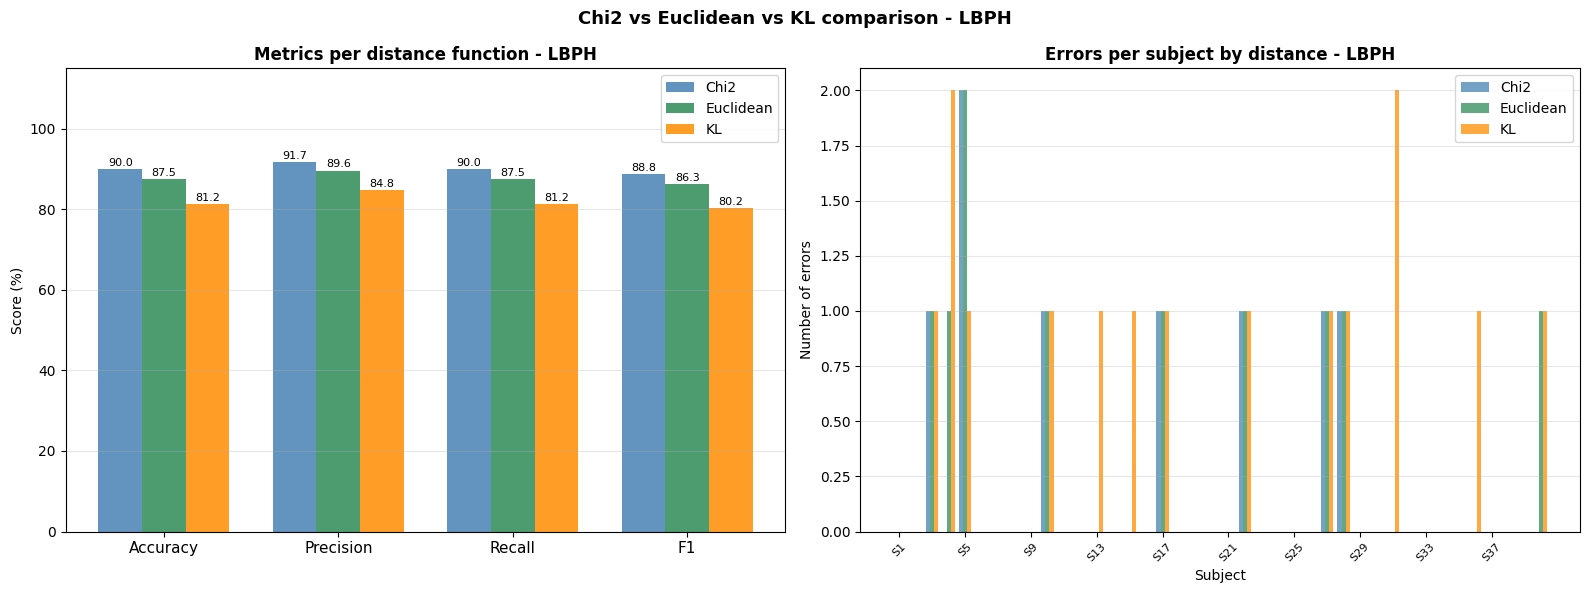

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compare_distances_lbph(X_test, y_test, subject_models, n_points, radius, method, block_size):
    """Evaluate LBPH with the 3 distance functions and plot a comparison."""
    results = {}

    for dist_name, dist_fn in DISTANCE_FUNCTIONS.items():
        print(f"Evaluating LBPH + {dist_name}...", end=" ", flush=True)
        t_start = time.time()
        y_pred_d, _, _ = predict_lbph(
            X_test, subject_models, n_points, radius, method, block_size,
            distance_fn=dist_fn
        )
        t_end = time.time()
        acc  = accuracy_score(y_test, y_pred_d)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_d, average='macro', zero_division=0
        )
        results[dist_name] = {
            'y_pred': y_pred_d,
            'accuracy':   acc,
            'precision':  prec,
            'recall':     rec,
            'f1':         f1,
            'time_pred':  t_end - t_start,
        }
        print(f"Accuracy = {acc*100:.2f}%  |  F1 = {f1*100:.2f}%  |  t = {t_end-t_start:.4f}s")

    # -- Summary table --------------------------------------------------------
    print("\n" + "="*70)
    print("  DISTANCE COMPARISON - LBPH")
    print("="*70)
    print(f"{'Distance':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Time (s)':>10}")
    print("-"*70)
    for name, r in results.items():
        print(f"{name:<15} {r['accuracy']*100:>9.2f}%  {r['precision']*100:>9.2f}%  "
              f"{r['recall']*100:>9.2f}%  {r['f1']*100:>9.2f}%  {r['time_pred']:>10.4f}")
    print("="*70)

    # -- Plot 1: metric bars --------------------------------------------------
    metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
    metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
    dist_names = list(results.keys())
    colors = ['steelblue', 'seagreen', 'darkorange']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    x = np.arange(len(metrics_keys))
    width = 0.25
    for i, (dist_name, color) in enumerate(zip(dist_names, colors)):
        vals = [results[dist_name][m] * 100 for m in metrics_keys]
        bars = ax.bar(x + i*width - width, vals, width,
                      label=dist_name, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=11)
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 115)
    ax.set_title("Metrics per distance function - LBPH", fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # -- Plot 2: errors per subject -------------------------------------------
    ax2 = axes[1]
    n_subjects = len(np.unique(y_test))
    errors_per_subject = {}
    for dist_name in dist_names:
        errs = []
        for sid in range(n_subjects):
            idx = np.where(y_test == sid)[0]
            errs.append(np.sum(results[dist_name]['y_pred'][idx] != sid))
        errors_per_subject[dist_name] = errs

    x2 = np.arange(n_subjects)
    w2 = 0.25
    for i, (dist_name, color) in enumerate(zip(dist_names, colors)):
        ax2.bar(x2 + i*w2 - w2, errors_per_subject[dist_name], w2,
                label=dist_name, color=color, alpha=0.75)
    ax2.set_xlabel("Subject")
    ax2.set_ylabel("Number of errors")
    ax2.set_title("Errors per subject by distance - LBPH", fontweight='bold')
    ax2.set_xticks(x2[::4])
    ax2.set_xticklabels([f"S{i+1}" for i in range(0, n_subjects, 4)], rotation=45, fontsize=8)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle("Chi2 vs Euclidean vs KL comparison - LBPH", fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    return results

dist_comparison_results = compare_distances_lbph(
    X_test, y_test, subject_models, N_POINTS, RADIUS, METHOD, BLOCK_SIZE
)

---
##  Method 2 — Eigenfaces 

### Principle

Pipeline:
1. Flatten each image (112x92) into a 10,304-dimensional vector
2. Apply PCA: find the directions of maximum variance in pixel space  
   -> the eigenvectors are the "eigenfaces" (ghost faces)
3. Project each image into the reduced PCA space (`N_COMPONENTS = 100`)
4. Classify with an RBF SVM in this compressed space

Advantages:  
- Noise reduction (low-variance components are discarded)  
- Dimensional compression: 10,304 -> 100 dimensions  

Limitations:
- Sensitive to lighting and pose variations (it captures global variance)


Flattened vectors - train : (320, 10304) | test : (80, 10304)

Varying the number of PCA components:
  n_components=  20 -> explained variance:  70.5% | Accuracy: 96.25%
  n_components=  60 -> explained variance:  84.6% | Accuracy: 96.25%
  n_components=  80 -> explained variance:  87.8% | Accuracy: 95.00%
  n_components= 100 -> explained variance:  90.2% | Accuracy: 93.75%
  n_components= 150 -> explained variance:  94.2% | Accuracy: 92.50%


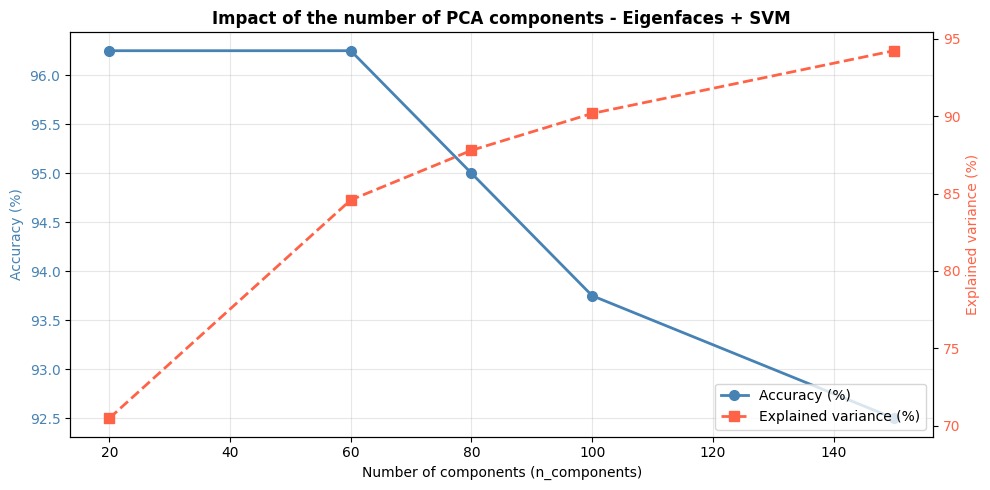


Best n_components : 20 (Accuracy = 96.25%)

Applying PCA with 20 components...
Variance explained by 20 components : 70.5%
Shape after PCA - train : (320, 20) | test : (80, 20)
PCA time : 0.878s


In [12]:
from sklearn.decomposition import PCA

# -- 1. Flatten the images ----------------------------------------------------
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float64)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1).astype(np.float64)

print(f"Flattened vectors - train : {X_train_flat.shape} | test : {X_test_flat.shape}")

# -- 2. Impact of the number of PCA components --------------------------------
N_COMPONENTS_LIST = [20, 60, 80, 100, 150]
acc_by_ncomp = {}

print("\nVarying the number of PCA components:")
for n in N_COMPONENTS_LIST:
    pca_tmp = PCA(n_components=n, whiten=True)
    Xtr_tmp = pca_tmp.fit_transform(X_train_flat)
    Xte_tmp = pca_tmp.transform(X_test_flat)
    var_exp  = np.sum(pca_tmp.explained_variance_ratio_) * 100
    svm_tmp  = Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf", C=10, gamma="scale"))])
    svm_tmp.fit(Xtr_tmp, y_train)
    acc_tmp  = accuracy_score(y_test, svm_tmp.predict(Xte_tmp)) * 100
    acc_by_ncomp[n] = (acc_tmp, var_exp)
    print(f"  n_components={n:4d} -> explained variance: {var_exp:5.1f}% | Accuracy: {acc_tmp:.2f}%")

# -- Variance & accuracy vs n_components --------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ns   = list(acc_by_ncomp.keys())
accs = [acc_by_ncomp[n][0] for n in ns]
vars_= [acc_by_ncomp[n][1] for n in ns]

ax1.plot(ns, accs,  "o-", color="steelblue", linewidth=2, markersize=7, label="Accuracy (%)")
ax2.plot(ns, vars_, "s--", color="tomato",   linewidth=2, markersize=7, label="Explained variance (%)")

ax1.set_xlabel("Number of components (n_components)")
ax1.set_ylabel("Accuracy (%)", color="steelblue")
ax2.set_ylabel("Explained variance (%)", color="tomato")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="tomato")
ax1.set_title("Impact of the number of PCA components - Eigenfaces + SVM", fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -- Pick the best n_components -----------------------------------------------
best_n = max(acc_by_ncomp, key=lambda n: acc_by_ncomp[n][0])
print(f"\nBest n_components : {best_n} (Accuracy = {acc_by_ncomp[best_n][0]:.2f}%)")

# -- 2. Final PCA with the best n ---------------------------------------------
N_COMPONENTS = best_n
print(f"\nApplying PCA with {N_COMPONENTS} components...")
t7 = time.time()
pca = PCA(n_components=N_COMPONENTS, whiten=True)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)
t8 = time.time()

variance_cumulee = np.sum(pca.explained_variance_ratio_) * 100
print(f"Variance explained by {N_COMPONENTS} components : {variance_cumulee:.1f}%")
print(f"Shape after PCA - train : {X_train_pca.shape} | test : {X_test_pca.shape}")
print(f"PCA time : {t8-t7:.3f}s")


### 2.1 Eigenfaces visualisation

The first components capture global variations (lighting, pose);  
later components encode increasingly fine details.


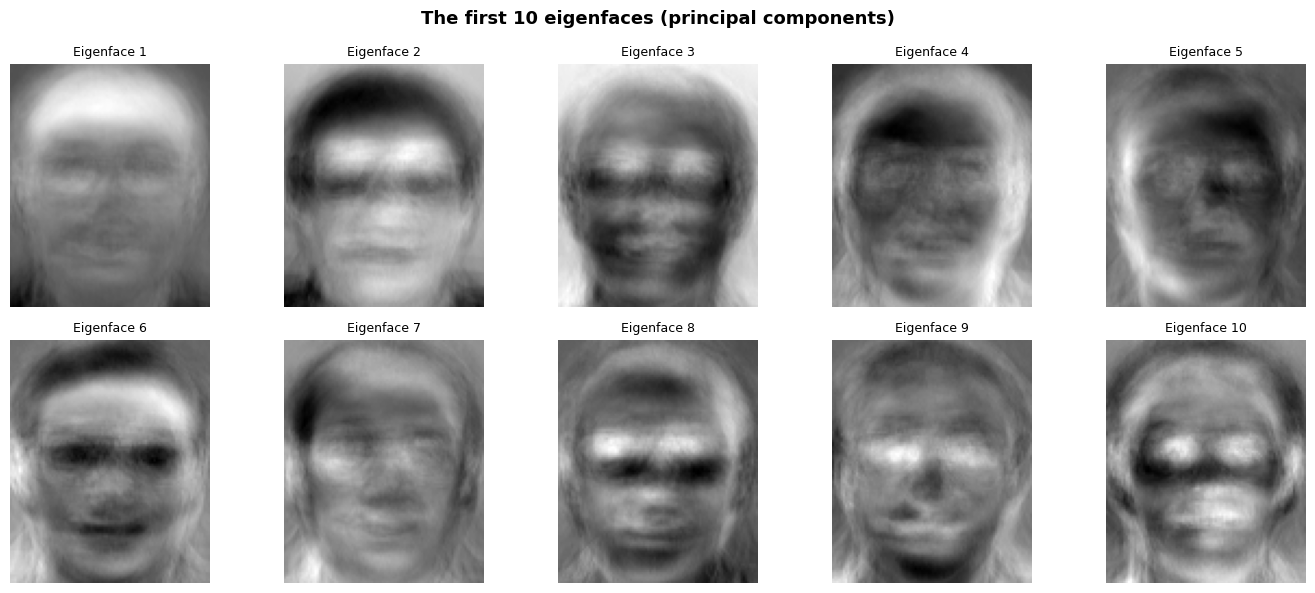

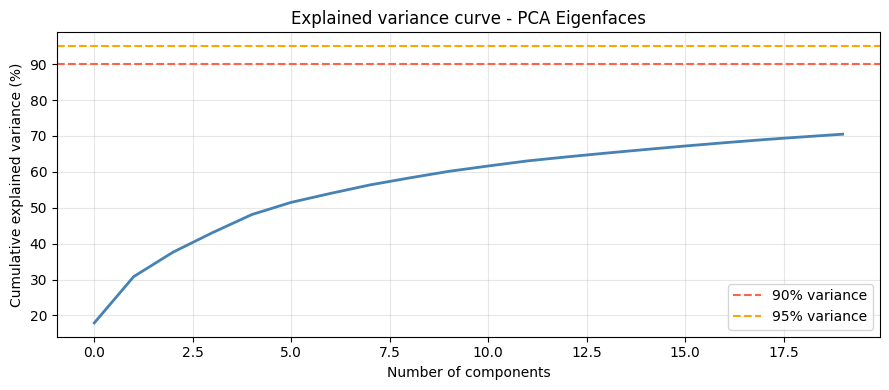

In [13]:
# -- Eigenfaces visualisation -------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    eigenface = pca.components_[i].reshape(112, 92)
    ax.imshow(eigenface, cmap="gray")
    ax.set_title(f"Eigenface {i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("The first 10 eigenfaces (principal components)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -- Cumulative explained variance curve --------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100,
         color="steelblue", linewidth=2)
plt.axhline(y=90, color="tomato",  linestyle="--", label="90% variance")
plt.axhline(y=95, color="orange",  linestyle="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Explained variance curve - PCA Eigenfaces")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Mean Face

Before visualising the eigenfaces, the **mean face** is computed:
- The **global mean face** is the average of all 320 training images: it represents a "neutral" face of the dataset.
- The **per-subject mean faces** show the characteristic texture and facial structure of each person.

PCA is applied **to the deviations** from this mean face — the eigenfaces therefore capture the most important directions of variation around this reference.


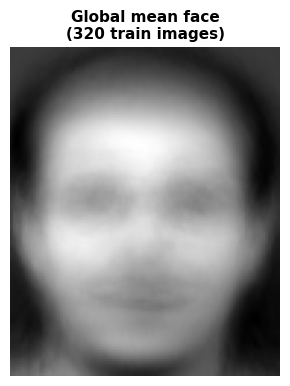

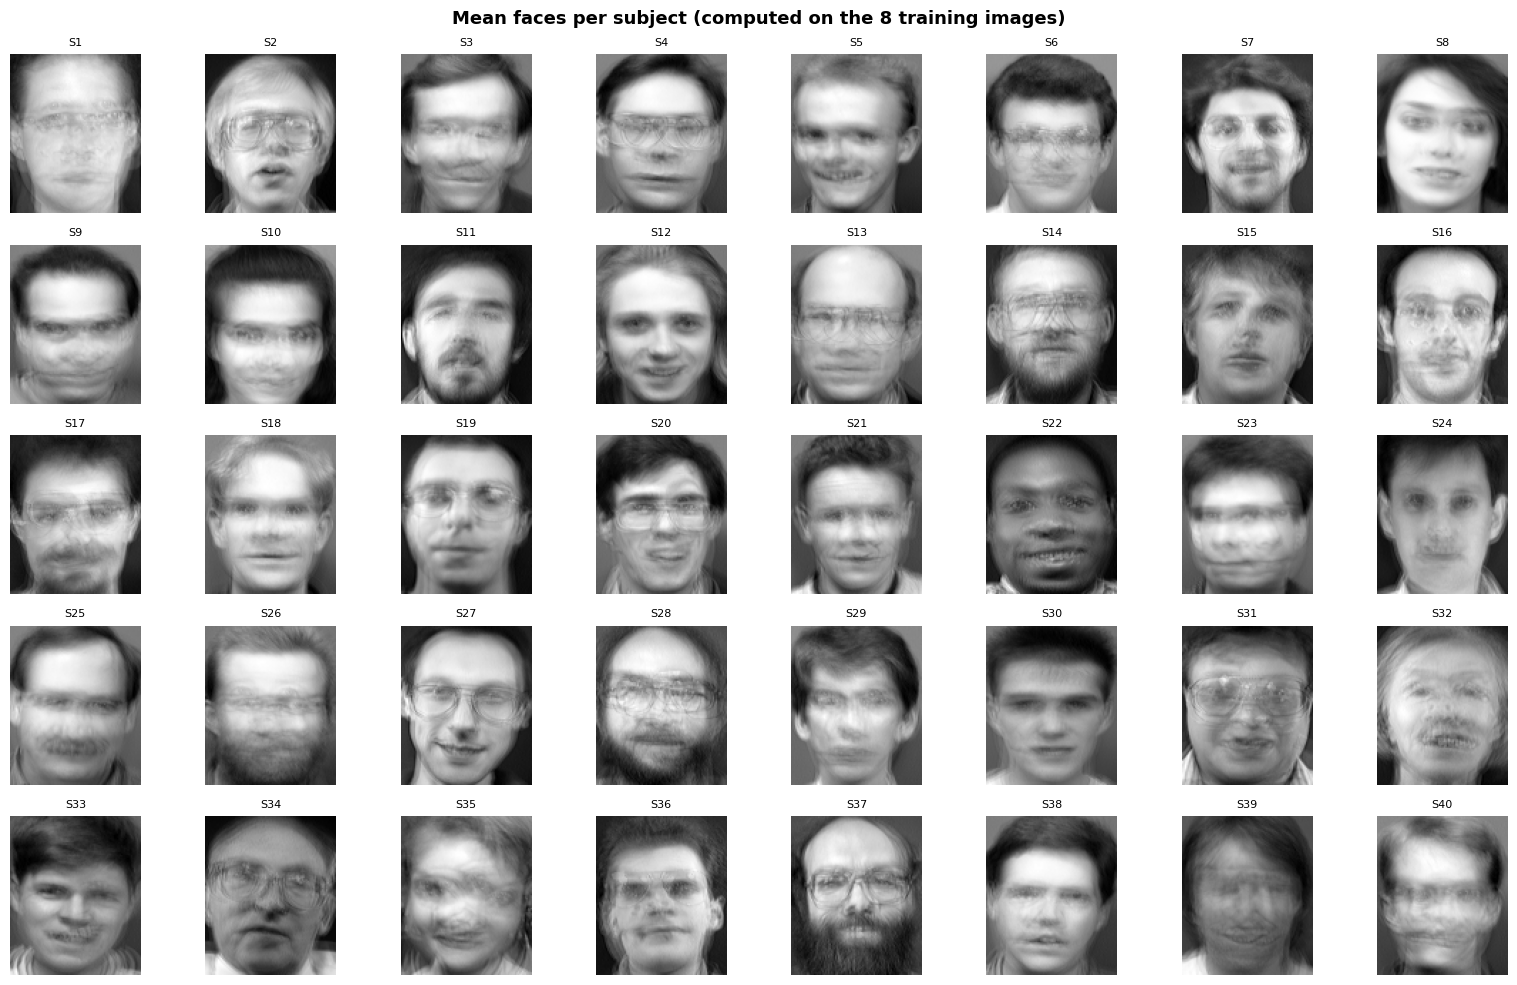

In [14]:
# -- Global and per-subject mean faces ----------------------------------------

# Global mean face (over the whole training set)
mean_face_global = X_train_flat.mean(axis=0).reshape(112, 92)

# Mean face per subject
mean_faces = []
for subject_id in range(40):
    idx = np.where(y_train == subject_id)[0]
    mean_face = X_train_flat[idx].mean(axis=0).reshape(112, 92)
    mean_faces.append(mean_face)

# -- Global mean face ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
ax.imshow(mean_face_global, cmap="gray")
ax.set_title("Global mean face\n(320 train images)", fontsize=11, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# -- Per-subject mean faces ---------------------------------------------------
fig, axes = plt.subplots(5, 8, figsize=(16, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(mean_faces[i], cmap="gray")
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Mean faces per subject (computed on the 8 training images)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Training the SVM in the PCA space

In [ ]:
# -- 3. SVM on the PCA space --------------------------------------------------
eigenface_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr"))
])

print("Training SVM on Eigenfaces features...")
t9  = time.time()
eigenface_svm.fit(X_train_pca, y_train)
t10 = time.time()
TIME_EIG_TRAIN = t10 - t9

t11 = time.time()
y_pred_eig = eigenface_svm.predict(X_test_pca)
t12 = time.time()
TIME_EIG_PRED = t12 - t11

print(f"Training finished in {TIME_EIG_TRAIN:.3f}s")
print(f"Eigenfaces accuracy : {accuracy_score(y_test, y_pred_eig)*100:.2f}%")


Training SVM on Eigenfaces features...
Training finished in 0.027s
Eigenfaces accuracy : 96.25%


---
## Comparative evaluation — LBPH vs Eigenfaces

Both methods are compared on the **same test data** (80 images, seed=42).  
Reported metrics are **macro-averaged** over the 40 classes.



  LBPH + Chi2 (block=8)
  Accuracy  :  90.00%
  Precision :  91.67%  (macro)
  Recall    :  90.00%  (macro)
  F1-score  :  88.83%  (macro)
  Train     : 10.343s
  Predict   : 2.5025s


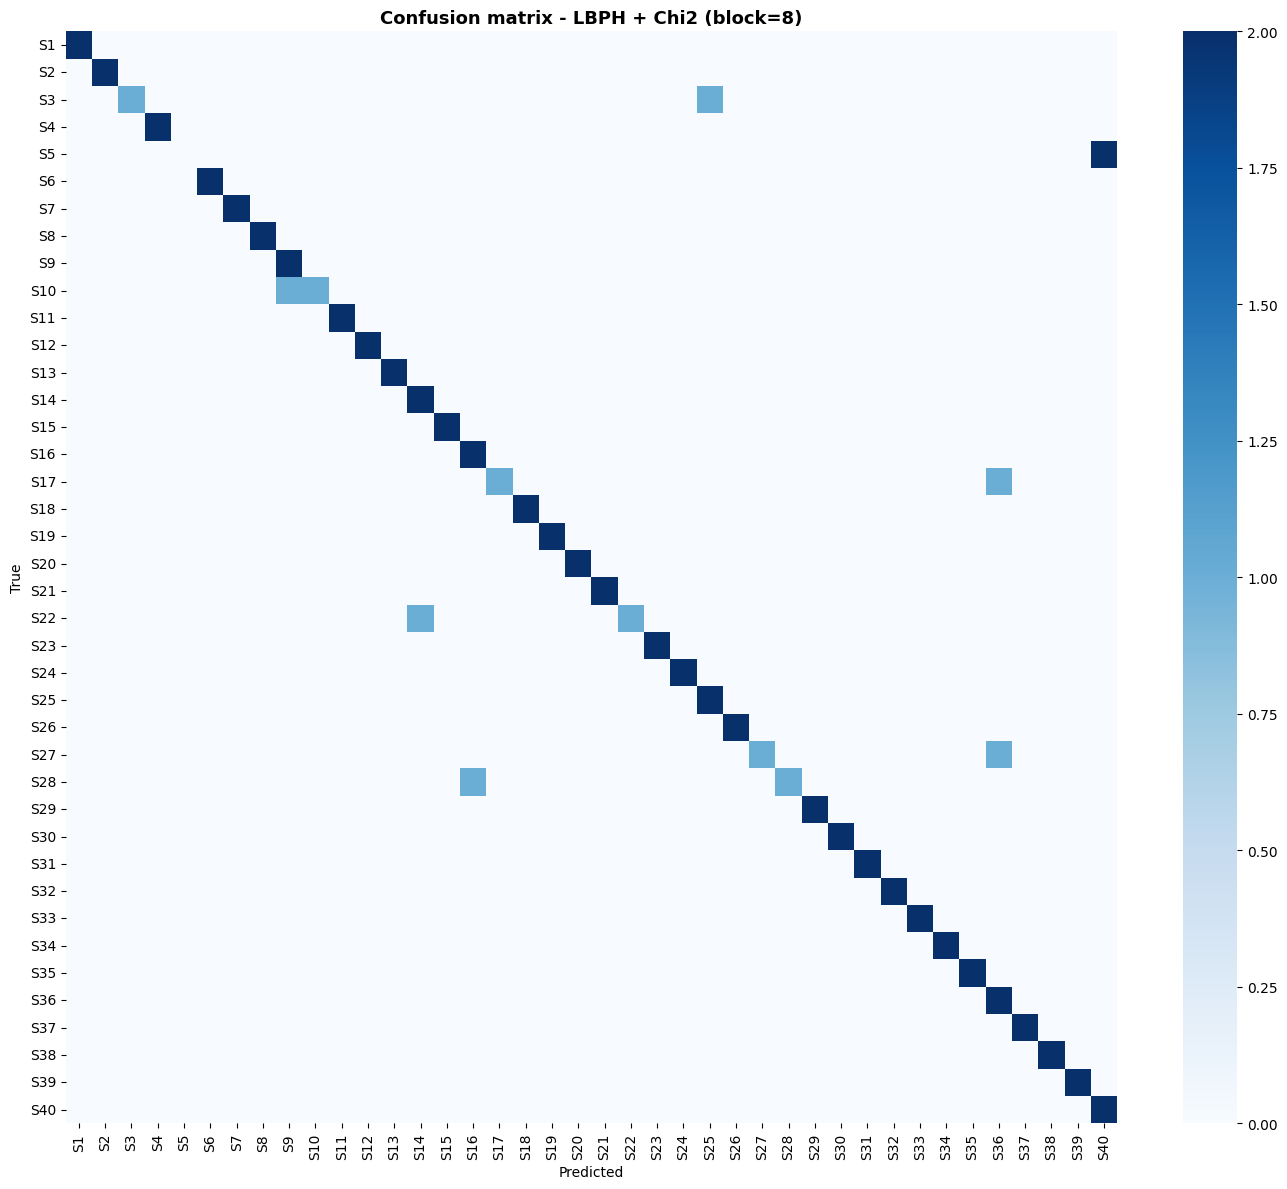

In [ ]:
def full_evaluate(y_test, y_pred, method_name, time_train=None, time_pred=None):
    """Evaluate a method and return a summary dict."""
    acc  = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    print(f"\n{'='*55}")
    print(f"  {method_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:6.2f}%")
    print(f"  Precision : {prec*100:6.2f}%  (macro)")
    print(f"  Recall    : {rec*100:6.2f}%  (macro)")
    print(f"  F1-score  : {f1*100:6.2f}%  (macro)")
    if time_train: print(f"  Train     : {time_train:.3f}s")
    if time_pred:  print(f"  Predict   : {time_pred:.4f}s")
    print(f"{'='*55}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=[f"S{i+1}" for i in range(40)],
                yticklabels=[f"S{i+1}" for i in range(40)])
    plt.title(f"Confusion matrix - {method_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

    return {"Method": method_name, "Accuracy": acc,
            "Precision": prec, "Recall": rec, "F1": f1,
            "Train (s)": round(time_train, 3) if time_train else "-",
            "Pred (s)":  round(time_pred,  4) if time_pred  else "-"}

# -- LBPH evaluation ----------------------------------------------------------
results_lbph = full_evaluate(
    y_test, y_pred_lbph,
    method_name=f"LBPH + Chi2 (block={BLOCK_SIZE})",
    time_train=TIME_LBPH_TRAIN, time_pred=TIME_LBPH_PRED
)



  Eigenfaces PCA(20) + SVM
  Accuracy  :  96.25%
  Precision :  97.92%  (macro)
  Recall    :  96.25%  (macro)
  F1-score  :  96.17%  (macro)
  Train     : 0.027s
  Predict   : 0.0042s


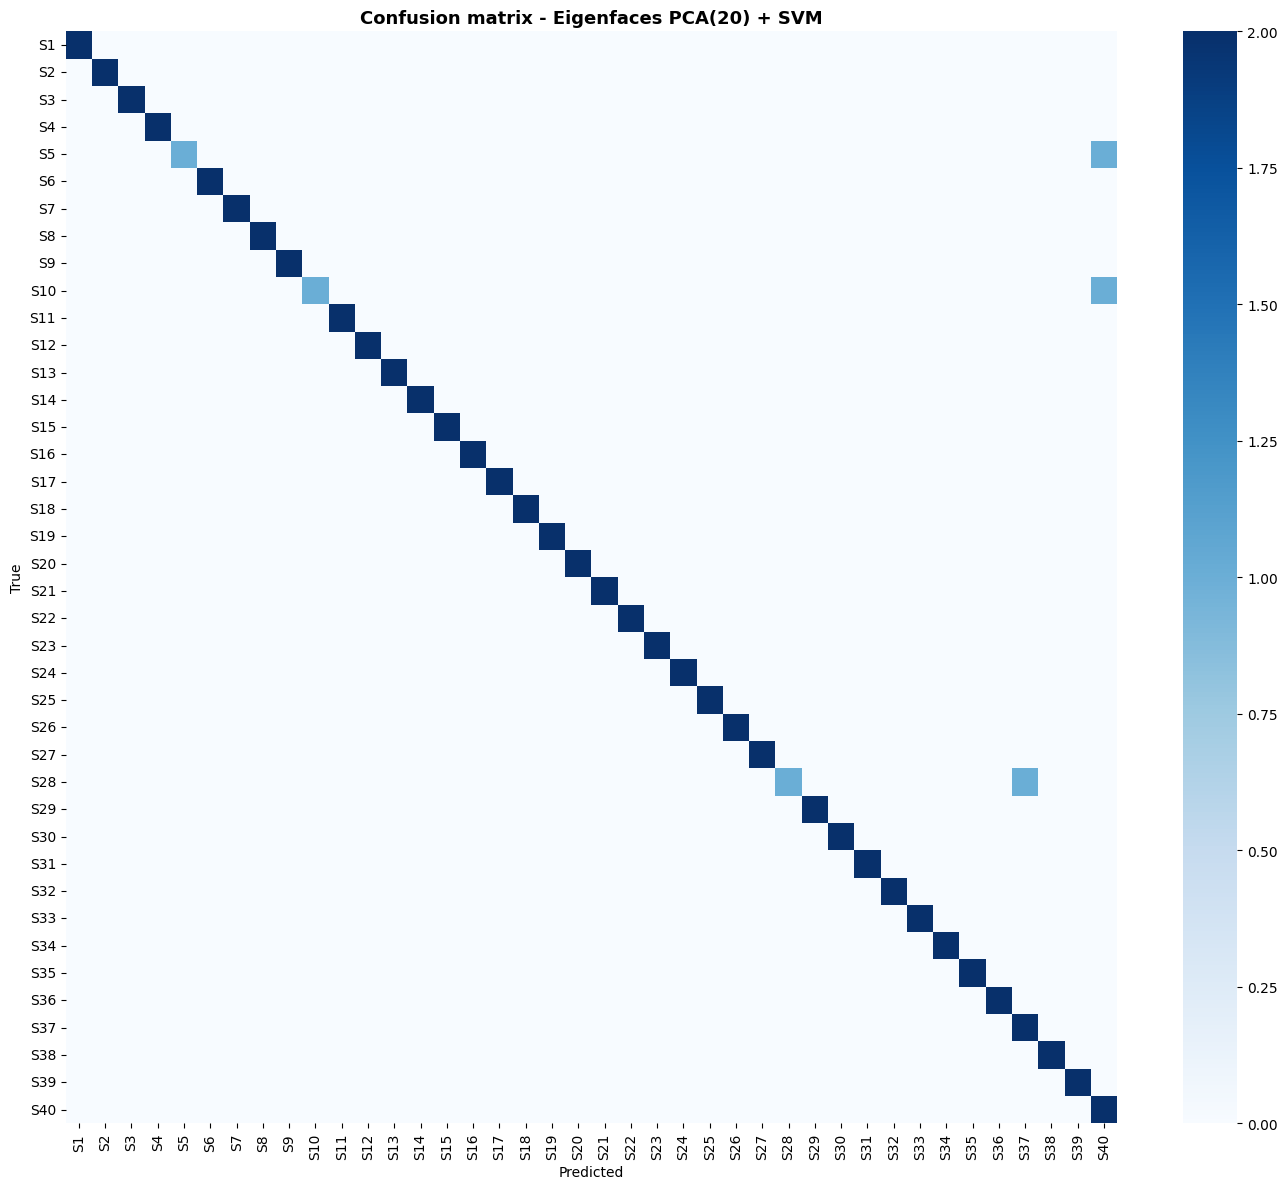

In [ ]:
# -- Eigenfaces evaluation ----------------------------------------------------
results_eig = full_evaluate(
    y_test, y_pred_eig,
    method_name=f"Eigenfaces PCA({N_COMPONENTS}) + SVM",
    time_train=TIME_EIG_TRAIN, time_pred=TIME_EIG_PRED
)


### Summary table and comparison plot


  SUMMARY TABLE - LBPH vs Eigenfaces
                  Method Accuracy Precision Recall     F1  Train (s)  Pred (s)
   LBPH + Chi2 (block=8)    90.0%    91.67%  90.0% 88.83%     10.343    2.5025
Eigenfaces PCA(20) + SVM   96.25%    97.92% 96.25% 96.17%      0.027    0.0042


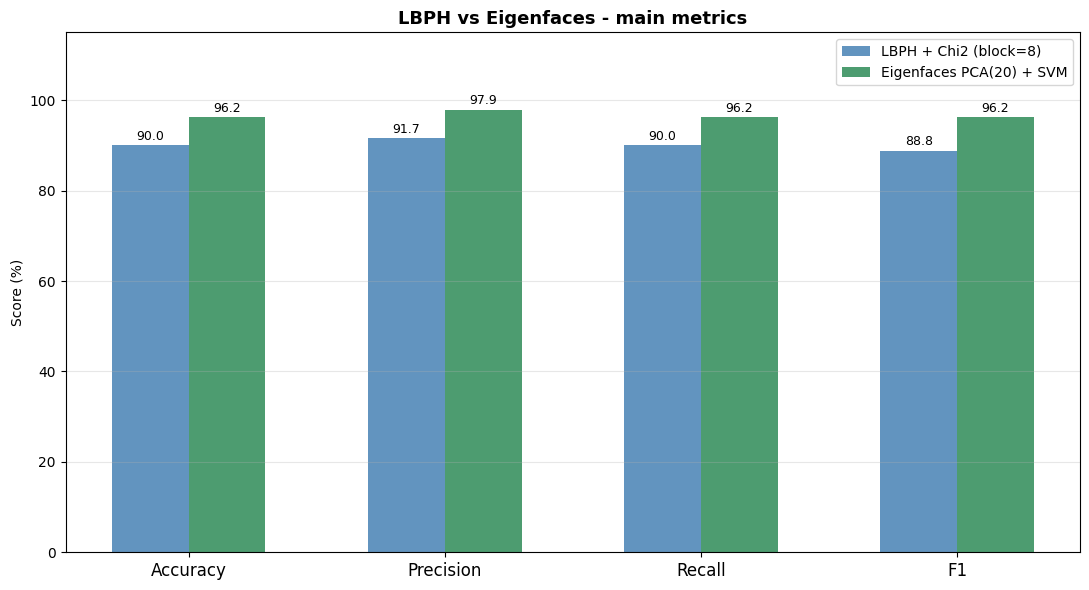

In [ ]:
# -- Table --------------------------------------------------------------------
results_all = [results_lbph, results_eig]
df = pd.DataFrame(results_all)

df_display = df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    df_display[col] = (df_display[col] * 100).round(2).astype(str) + "%"

print("\n" + "="*70)
print("  SUMMARY TABLE - LBPH vs Eigenfaces")
print("="*70)
print(df_display.to_string(index=False))
print("="*70)

# -- Comparison plot ----------------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1"]
fig, ax = plt.subplots(figsize=(11, 6))
x, width = np.arange(len(metrics)), 0.30
colors   = ["steelblue", "seagreen"]

for i, (row, color) in enumerate(zip(results_all, colors)):
    vals = [row["Accuracy"]*100, row["Precision"]*100,
            row["Recall"]*100,   row["F1"]*100]
    bars = ax.bar(x + i*width - width/2, vals, width,
                  label=row["Method"], color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 115)
ax.set_title("LBPH vs Eigenfaces - main metrics",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Error analysis — misclassified images

Looking at misclassified images helps understand edge cases:  
unusual expressions, atypical lighting, inter-subject resemblance.


=== LBPH - errors with true / predicted comparison ===

LBPH + Chi2 (block=8) : 8 error(s) out of 80 images


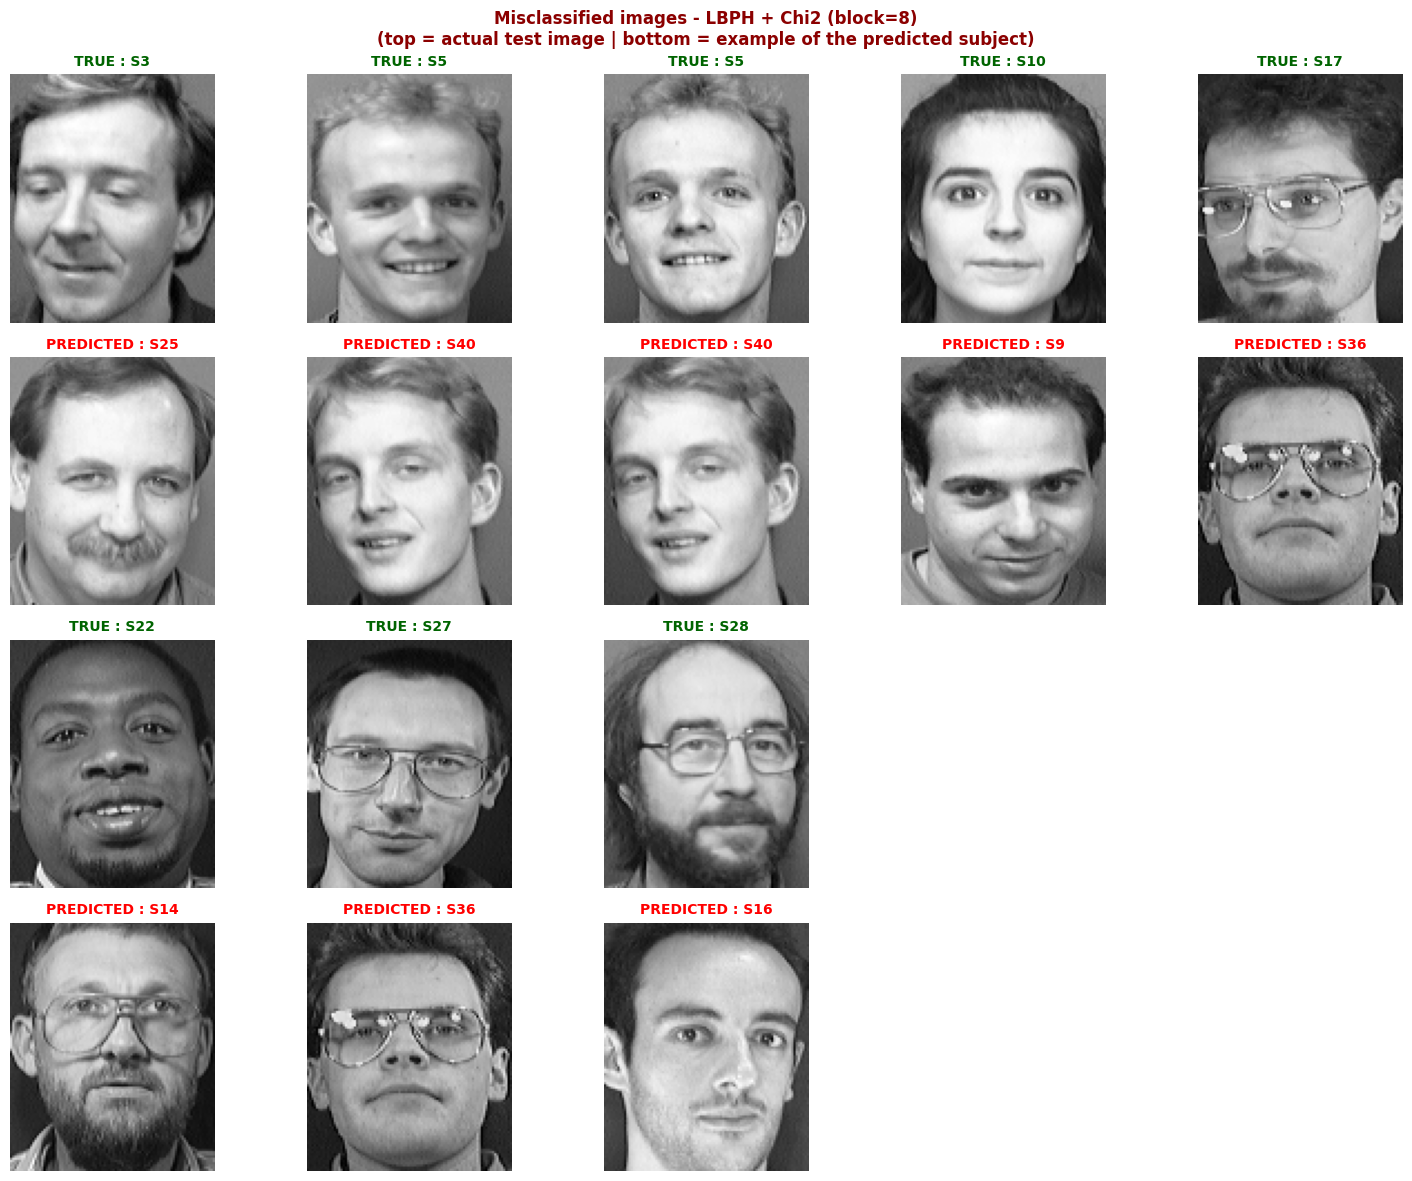


=== Eigenfaces - misclassified images ===

Eigenfaces PCA(20) + SVM : 3 error(s) out of 80 images


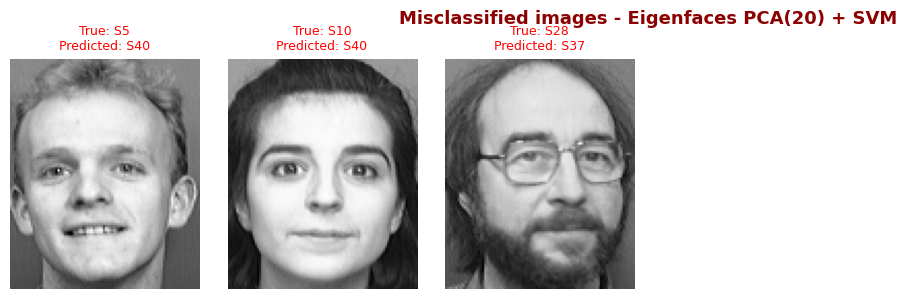

In [ ]:
def plot_misclassified(X_test, y_test, y_pred, method_name, max_show=10,
                       X_train=None, y_train=None, show_predicted_face=False):
    """
    Display the misclassified images.
    If show_predicted_face=True and X_train/y_train are provided:
      - Top row    : test image (true subject)
      - Bottom row : train image of the predicted subject (for comparison)
    """
    errors = np.where(y_test != y_pred)[0]
    print(f"\n{method_name} : {len(errors)} error(s) out of {len(y_test)} images")
    if len(errors) == 0:
        print("Perfect classification!"); return

    n_show = min(len(errors), max_show)

    if show_predicted_face and X_train is not None and y_train is not None:
        # -- Side-by-side mode: (true | predicted) ----------------------------
        n_cols = min(n_show, 5)
        n_rows = int(np.ceil(n_show / n_cols))
        fig, axes = plt.subplots(n_rows * 2, n_cols,
                                 figsize=(n_cols * 3, n_rows * 6))
        if n_rows * 2 == 2 and n_cols == 1:
            axes = axes.reshape(2, 1)
        elif n_rows * 2 == 2:
            axes = axes.reshape(2, n_cols)
        # axes shape: (2*n_rows, n_cols)

        for k, idx in enumerate(errors[:n_show]):
            row_top = (k // n_cols) * 2
            row_bot = row_top + 1
            col     = k % n_cols

            real_sid = y_test[idx]
            pred_sid = y_pred[idx]

            # Test image (true subject)
            ax_real = axes[row_top, col]
            ax_real.imshow(X_test[idx], cmap='gray')
            ax_real.set_title(f"TRUE : S{real_sid+1}", fontsize=10,
                              color='darkgreen', fontweight='bold')
            ax_real.axis('off')

            # One image of the predicted subject (taken from train)
            pred_train_idx = np.where(y_train == pred_sid)[0][0]
            ax_pred = axes[row_bot, col]
            ax_pred.imshow(X_train[pred_train_idx], cmap='gray')
            ax_pred.set_title(f"PREDICTED : S{pred_sid+1}", fontsize=10,
                              color='red', fontweight='bold')
            ax_pred.axis('off')

        # Hide unused axes
        for k in range(n_show, n_rows * n_cols):
            row_top = (k // n_cols) * 2
            row_bot = row_top + 1
            col     = k % n_cols
            if row_top < axes.shape[0]:
                axes[row_top, col].set_visible(False)
            if row_bot < axes.shape[0]:
                axes[row_bot, col].set_visible(False)

        plt.suptitle(f"Misclassified images - {method_name}\n"
                     f"(top = actual test image | bottom = example of the predicted subject)",
                     fontsize=12, fontweight='bold', color='darkred')
        plt.tight_layout(); plt.show()

    else:
        # -- Plain mode: image only -------------------------------------------
        n_cols = 6
        n_rows = int(np.ceil(n_show / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.2, n_rows*3))
        axes = np.array(axes).ravel()
        for i, idx in enumerate(errors[:n_show]):
            axes[i].imshow(X_test[idx], cmap='gray')
            axes[i].set_title(f"True: S{y_test[idx]+1}\nPredicted: S{y_pred[idx]+1}",
                              fontsize=9, color='red')
            axes[i].axis('off')
        for j in range(n_show, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f"Misclassified images - {method_name}",
                     fontsize=13, fontweight='bold', color='darkred')
        plt.tight_layout(); plt.show()

# -- LBPH display: side by side (true | predicted) ----------------------------
print("=== LBPH - errors with true / predicted comparison ===")
plot_misclassified(
    X_test, y_test, y_pred_lbph,
    method_name=f"LBPH + Chi2 (block={BLOCK_SIZE})",
    max_show=10,
    X_train=X_train, y_train=y_train,
    show_predicted_face=True
)

# -- Eigenfaces display: plain mode -------------------------------------------
print("\n=== Eigenfaces - misclassified images ===")
plot_misclassified(
    X_test, y_test, y_pred_eig,
    method_name=f"Eigenfaces PCA({N_COMPONENTS}) + SVM",
    max_show=12
)

---
##  Conclusion

### Method summary

| Method | Type | Descriptor | Classifier |
|---|---|---|---|
| **LBPH + Chi2** | Training-free | Local textures (block-wise LBP) | Chi2 distance |
| **Eigenfaces** | ML training | Global structure (PCA) | RBF SVM |

### Key takeaways

- **LBPH**: fast, no explicit training phase, robust to lighting variations  
  because it works on **local gradients**. Limitation: the Chi2 comparison is less  
  flexible than a learned classifier.

- **Eigenfaces**: a historical baseline, effective thanks to PCA compression  
  and the power of the SVM. More sensitive to lighting and pose  
  because PCA captures the **global variance** of the pixels.

- With only **2 test images per subject**, the metrics are sensitive to the random  
  split. Cross-validation (k-fold) would give more stable results.

### Possible improvements

- **Cross-validation** for more robust results  
- **Combining LBPH + Eigenfaces** (feature fusion) for a richer descriptor  
- **Data augmentation** (flip, Gaussian noise) to improve generalisation  
- **Deep Learning** (FaceNet, ArcFace) for benchmarks on harder datasets (LFW, etc.)
